# Anomaly Detection

Detect **price anomalies** — listings whose price is unusual for their category, the kind a scrape error, a mispriced variant, or a spammy duplicate would produce. Two methods, both pure pandas/numpy (no new deps):

- **A. Global IQR** on `log1p(Price)` — flags prices far outside the overall distribution. Coarse; ignores category.
- **B. Per-section robust z (median/MAD)** on `log1p(Price)` — the meaningful one: flags prices that don't fit *their own section*. Robust to the skew and to sections with very different medians (Herbs ฿70 vs Protein ฿825).

Listings flagged by **both** are the high-confidence anomalies.

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

DATA = Path('../dataset/health_and_wellness_cleaned_20230810_213000.csv')
FIGS = Path('figures'); FIGS.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
df['Price'] = pd.to_numeric(
    df['Price'].astype(str).str.replace('฿', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce',
)
assert df['Price'].isna().sum() == 0
df['log_price'] = np.log1p(df['Price'])
df.shape

(68499, 8)

## 0. Eliminate exact duplicates

The raw 68,499 rows are ~2,600 real listings repeated ~26x (96% full duplicates). Running
anomaly detection on the inflated set makes the same mispriced listing count N times —
the flagged "high-z" rows are near-identical copies of one product. Drop exact duplicates
first so each listing is scored once.

In [24]:
n_raw = len(df)
n_dup = df.duplicated().sum()
print(f'rows: {n_raw:,} | full-duplicate: {n_dup:,} ({100*n_dup/n_raw:.1f}%)')

df = df.drop_duplicates().reset_index(drop=True)
assert df.duplicated().sum() == 0
print(f'after dedup: {len(df):,} rows ({n_raw - len(df):,} removed)')

rows: 68,499 | full-duplicate: 65,877 (96.2%)
after dedup: 2,622 rows (65,877 removed)


## 1. Method A — global IQR

Tukey fences on `log1p(Price)`. Anything outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.

In [25]:
q1, q3 = df['log_price'].quantile([.25, .75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df['anom_iqr'] = (df['log_price'] < lo) | (df['log_price'] > hi)
print(f'A global IQR: {df["anom_iqr"].sum()} of {len(df)} ({df["anom_iqr"].mean()*100:.1f}%)')
print(f'  fences: ฿{np.expm1(lo):.0f} .. ฿{np.expm1(hi):.0f}')

A global IQR: 24 of 2622 (0.9%)
  fences: ฿20 .. ฿5044


## 2. Method B — per-section robust z (median/MAD)

For each row, $z = 0.6745 \cdot (\log p - \text{median}_s) / \text{MAD}_s$ where $s$ is the row's `Section`. Flag $|z| > 3.5$ (≈3.5 robust sigmas). MAD replaced with `NaN` where zero (constant-price section) so those rows aren't flagged.

In [26]:
g = df.groupby('Section')['log_price']
med = g.transform('median')
mad = g.transform(lambda s: np.median(np.abs(s - np.median(s))))
mad = mad.replace(0, np.nan)
df['robust_z'] = 0.6745 * (df['log_price'] - med) / mad
df['anom_robust'] = df['robust_z'].abs() > 3.5

df['anom_both'] = df['anom_iqr'] & df['anom_robust']
print(f'B per-section |z|>3.5: {df["anom_robust"].sum()} ({df["anom_robust"].mean()*100:.1f}%)')
print(f'  both A & B: {df["anom_both"].sum()}')
df.loc[df['anom_robust'], 'Section'].value_counts().head(8)

B per-section |z|>3.5: 28 (1.1%)
  both A & B: 12


Section
Digestive Care                   7
Breast Enlargement               4
Multivitamins                    4
Whitening                        4
Acne Care                        3
Beauty Supplements Value Sets    2
Nutritional Foods & Drinks       1
Slimming Beverages               1
Name: count, dtype: int64

In [27]:
cols = ['Section', 'Name', 'Price', 'log_price', 'robust_z']
print('=== high-price anomalies (top 5 by z) ===')
print(df.nlargest(5, 'robust_z')[cols].to_string(max_colwidth=60))
print('\n=== low-price anomalies (bottom 5 by z) ===')
print(df.nsmallest(5, 'robust_z')[cols].to_string(max_colwidth=60))

=== high-price anomalies (top 5 by z) ===
                Section                                                         Name   Price  log_price  robust_z
619       Multivitamins  Coatex Dogs Cats Help Skin & Coat 240caps อาหารเสริม บำร...  2890.0   7.969358  5.038402
7             Acne Care  ชุดสวย ใส อ่อนวัย : 2-Collagen + 4-Vit C + 2-(4Greens) +...  5590.0   8.628913  4.763935
644       Multivitamins  ( นิภา 11 ) 4 แถม 7 นิภาคอลลาเจนรังนก วิตามินบำรุงผิว สล...  1950.0   7.576097  4.316214
169  Breast Enlargement                  💢ใหม่ล่าสุดปี 2023 Transino White C Premium  1290.0   7.163172  4.210779
25            Acne Care  New Nucera Plus (นูเซร่า พลัส) แถมฟรี Nucera Drink ปรับส...  3790.0   8.240385  4.137690

=== low-price anomalies (bottom 5 by z) ===
                           Section                                                         Name  Price  log_price  robust_z
596                  Multivitamins  Clover Plus VH Collagen Peptide Vitamin/ DB Collagen Pep...  13.00   

## 3. Visualize

Top: price-by-section boxplots (log x) with high-confidence anomalies overlaid. Bottom: histogram of per-section robust z with the ±3.5 threshold.

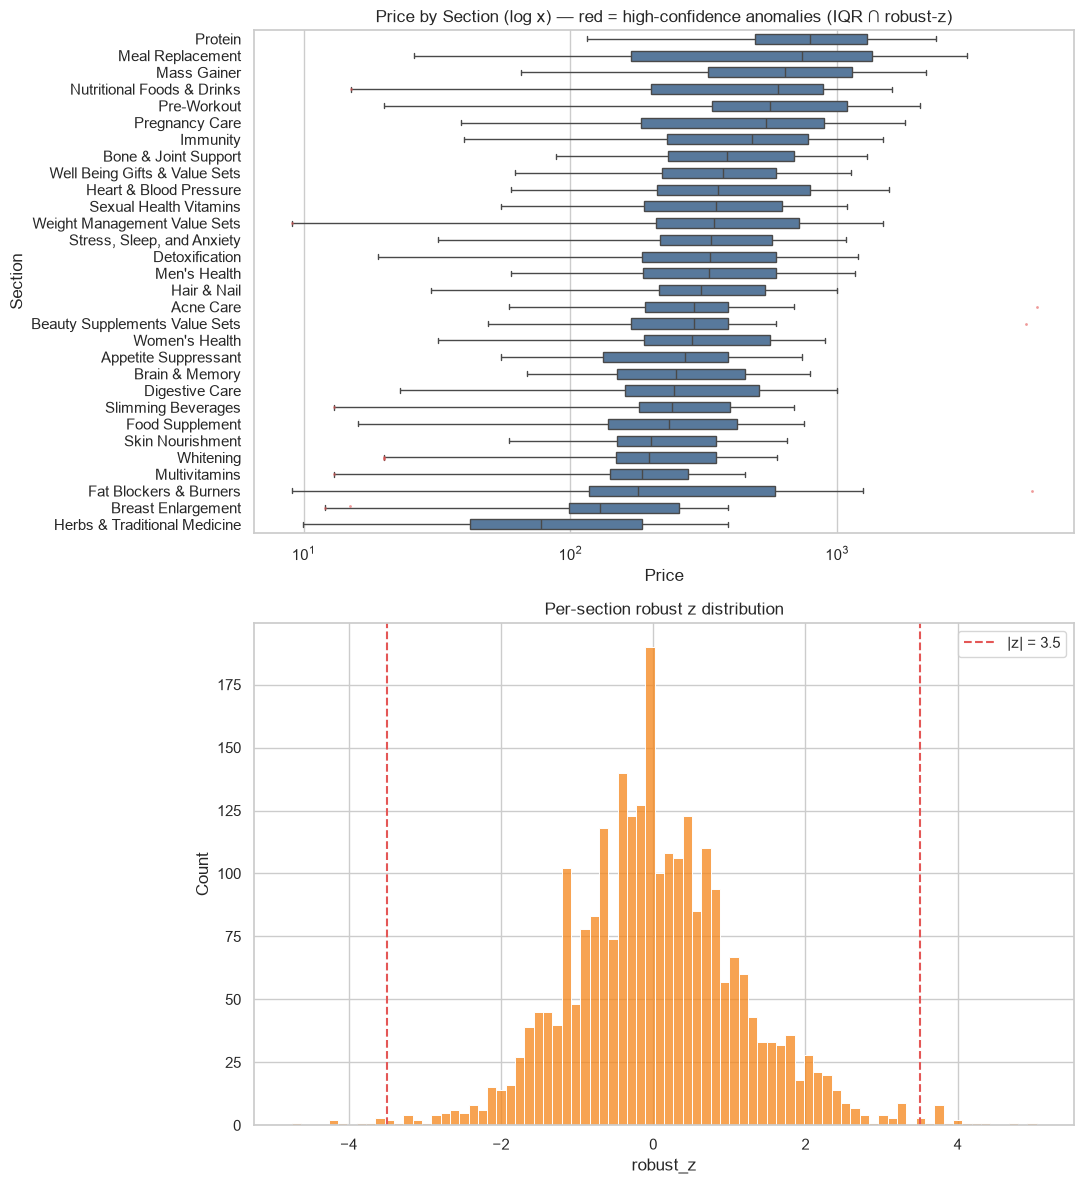

In [28]:
order = df.groupby('Section')['Price'].median().sort_values(ascending=False).index
fig, axes = plt.subplots(2, 1, figsize=(11, 12))

sns.boxplot(data=df, y='Section', x='Price', order=order, ax=axes[0],
            fliersize=0, color='#4C78A8', width=.6)
anom = df[df['anom_both']]
sns.stripplot(data=anom, y='Section', x='Price', order=order, ax=axes[0],
              color='#E45756', size=2, alpha=.6)
axes[0].set_xscale('log')
axes[0].set_title('Price by Section (log x) — red = high-confidence anomalies (IQR ∩ robust-z)')

sns.histplot(df['robust_z'].clip(-8, 9), bins=80, ax=axes[1], color='#F58518')
axes[1].axvline(-3.5, color='#E45756', ls='--', label='|z| = 3.5')
axes[1].axvline(3.5, color='#E45756', ls='--')
axes[1].set_title('Per-section robust z distribution')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGS / 'anomaly_price_by_section.png', dpi=120)
plt.show()

## 5. Outlier elimination

Drop the **high-confidence** anomalies (`anom_both` = IQR ∩ robust-z, 12 rows / 0.5% of the deduped set) and persist a cleaned dataset for the downstream Price regressor. Conservative by design — widen to `anom_robust` (28 rows) if a leaner training set is wanted. The helper columns are dropped so the output schema matches the original CSV.

In [29]:
DROP = 'anom_both'  # 'anom_robust' to drop all section-z outliers instead
clean = df[~df[DROP]].drop(columns=['log_price', 'anom_iqr', 'robust_z', 'anom_robust', 'anom_both'])

OUT = Path('../dataset/health_and_wellness_no_outliers.csv')
clean.to_csv(OUT, index=False)

assert list(clean.columns) == list(df.columns)[:7], 'schema drift'
assert len(clean) == len(df) - int(df[DROP].sum())
assert clean['Price'].isna().sum() == 0
print(f'before {len(df)} -> after {len(clean)} (dropped {len(df)-len(clean)}, {df[DROP].mean()*100:.1f}%)')
print(f'wrote {OUT} ({OUT.stat().st_size//1024} KB)')

pd.DataFrame({'before': df['Price'].describe(), 'after': clean['Price'].describe()}).round(1)

before 2622 -> after 2610 (dropped 12, 0.5%)
wrote ../dataset/health_and_wellness_no_outliers.csv (625 KB)


,before,after
count,2622.0,2610.0
mean,521.7,517.9
std,618.4,596.9
min,9.0,9.0
25%,165.2,169.0
50%,299.0,299.0
75%,650.0,650.0
max,5600.0,5600.0


/var/folders/z8/n13_r1ws7k57_fdtz3kwjmk00000gn/T/ipykernel_79093/4096227667.py:8: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/z8/n13_r1ws7k57_fdtz3kwjmk00000gn/T/ipykernel_79093/4096227667.py:9: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.savefig(FIGS / 'anomaly_before_after.png', dpi=120)
/Users/akarapongmba/Documents/GitHub/hs-practical-machine-learning-final-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


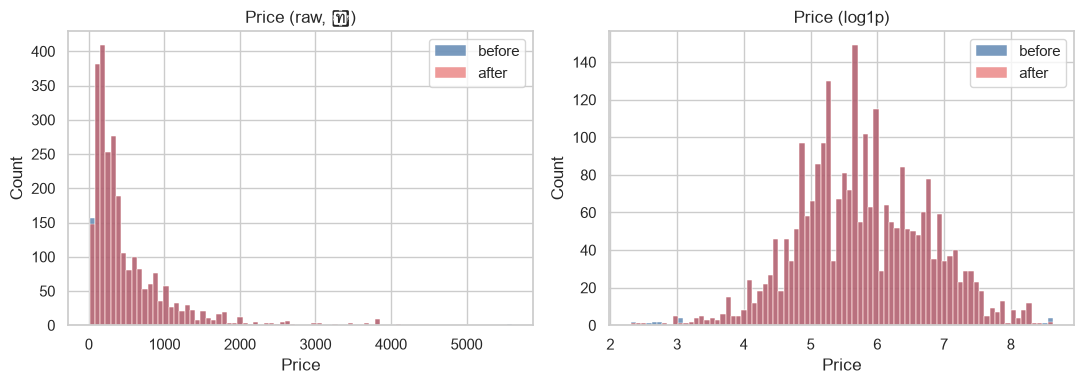

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Price'], bins=80, ax=axes[0], color='#4C78A8', label='before')
sns.histplot(clean['Price'], bins=80, ax=axes[0], color='#E45756', label='after', alpha=.6)
axes[0].set_title('Price (raw, ฿)'); axes[0].legend()
sns.histplot(np.log1p(df['Price']), bins=80, ax=axes[1], color='#4C78A8', label='before')
sns.histplot(np.log1p(clean['Price']), bins=80, ax=axes[1], color='#E45756', label='after', alpha=.6)
axes[1].set_title('Price (log1p)'); axes[1].legend()
fig.tight_layout()
fig.savefig(FIGS / 'anomaly_before_after.png', dpi=120)
plt.show()

## 4. Findings & next steps

**Elimination result** — after dedup (68,499 → 2,622 real listings), dropped 12 high-confidence rows (0.5%) → `dataset/health_and_wellness_no_outliers.csv` (**2,610 rows**, original schema, 625 KB). Price std ฿618 → ฿597; median ฿299 and quantiles unchanged; max ฿5,600 survives (a legit premium bundle, not flagged by both methods). Use this file as the regressor input.

**Anomaly counts** (on the deduped 2,622 rows)
- Global IQR: 0.9% (24 rows, fences ≈ ฿20 .. ฿5,044). Coarse — flags an expensive Protein set the same way it flags an expensive Herb.
- Per-section robust z (>3.5): 1.1% (28 rows). Concentrated in **Digestive Care** (7), **Breast Enlargement** (4), **Multivitamins** (4), **Whitening** (4), **Acne Care** (3) — sections with wide price spreads.
- High-confidence (both): 12 (0.5%) → **dropped** in §5.

**What the anomalies look like**
- High-z: ฿5,590 "ชุดสวยใสอ่อนวัย" collagen/Vit-C bundle in Acne Care; ฿2,890 Coatex pet supplement in Multivitamins; ฿3,790 Nucera Plus in Acne Care — premium bundles / large-count packs, legitimately pricier than their section median.
- Low-z: ฿9–฿15 single-serve sachets — LACTO-FIT ฿9, Nutri D-Day coffee ฿13, X-Boom ฿14.85, Clover Plus ฿13 — sample/loss-leader pricing, legit cheap for a one-stick listing.

**Why dedup first** — on the raw 68,499 rows the flagged set was dominated by the same product repeated ~26x (e.g. a ฿5,380 Yanhee set filled 5 of the top-5 high-z slots). Deduping before flagging scores each listing once, so the anomaly counts above reflect distinct products, not duplicate inflation.

**Upgrade path (not done here)**
- Multivariate: `IsolationForest` on `[log1p(Price), Section code, Shop Location code]` to catch location×section outliers — needs `scikit-learn` (add when the Ridge baseline in the EDA plan lands, since that needs it too).